# Exploratory Data Analysis

Phân tích và trực quan hóa dữ liệu prelabeled từ social media (Reddit, Facebook, Threads).

In [1]:
# Google Colab setup — mount Drive and set data path
# Skip this cell if running locally

import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = "/content/drive/MyDrive/social-data-normalizer/data"
    IN_COLAB = True
    print("Running on Google Colab")
except ImportError:
    DATA_DIR = "../data"
    IN_COLAB = False
    print("Running locally")

Running locally


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv(f"{DATA_DIR}/prelabeled/05_03_2026_gpt4omini.csv")
print(f"Total rows: {len(df)}")
df.head()

Total rows: 13943


,id,platform,text_clean,url,created_at,label
0,reddit:vietnamnation:1ram8as,reddit,Trong clip là một người dân vi phạm giao thông...,https://www.reddit.com/r/VietNamNation/comment...,2026-02-21T08:46:37+00:00,political
1,reddit:vietnam:1q86kix,reddit,"At Hồng Bàng Quarter District, Hạ Lý, nearly T...",https://www.reddit.com/r/VietNam/comments/1q86...,2026-01-09T12:06:27+00:00,neutral
2,reddit:vietnamtoancau:1j0u5z5,reddit,"Một chuyên gia ủng hộ Ukraine, thường xuyên ủn...",https://www.reddit.com/r/VietnamToanCau/commen...,2025-03-01T07:34:01+00:00,political
3,reddit:reviewnganhluat:1pi3pmq,reddit,Cái xã hội đểu giả này còn cái gì là thật nữa ...,https://www.reddit.com/r/reviewnganhluat/comme...,2025-12-09T10:04:02+00:00,political
4,reddit:vozforums:1psnmkg,reddit,Dạ có anh chị nào có thể chia sẻ kinh nghiệm h...,https://www.reddit.com/r/vozforums/comments/1p...,2025-12-22T02:07:53+00:00,stress


## Label Distribution

/var/folders/kl/9h9p1_m91nnddq1bc6sdfs140000gp/T/ipykernel_45296/1022169606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette="viridis")


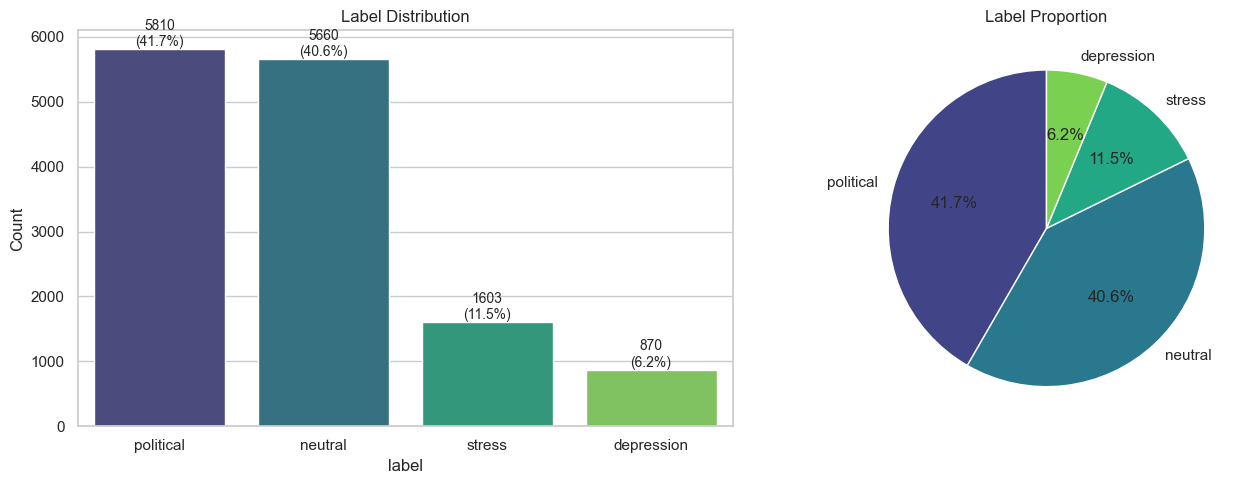

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts = df["label"].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("viridis", len(label_counts)))
axes[1].set_title("Label Proportion")

plt.tight_layout()
plt.show()

## Platform Distribution

/var/folders/kl/9h9p1_m91nnddq1bc6sdfs140000gp/T/ipykernel_45296/3175324349.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_counts.index, y=platform_counts.values, ax=axes[0], palette="Set2")


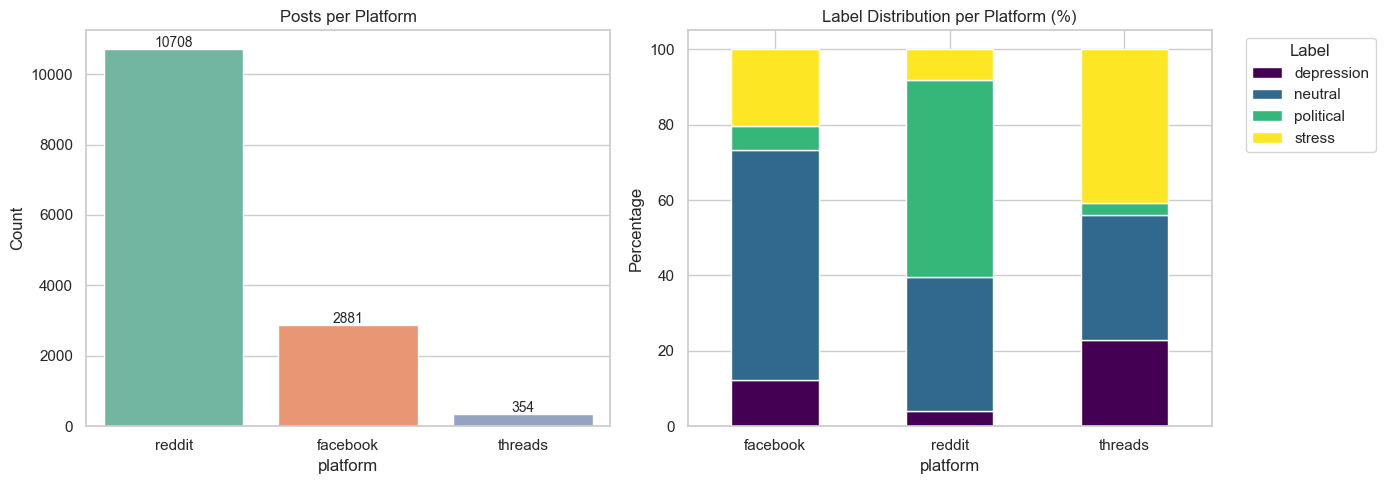

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posts per platform
platform_counts = df["platform"].value_counts()
sns.barplot(x=platform_counts.index, y=platform_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Posts per Platform")
axes[0].set_ylabel("Count")
for i, v in enumerate(platform_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=10)

# Label distribution per platform
ct = pd.crosstab(df["platform"], df["label"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Label Distribution per Platform (%)")
axes[1].set_ylabel("Percentage")
axes[1].legend(title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Text Length Analysis

/var/folders/kl/9h9p1_m91nnddq1bc6sdfs140000gp/T/ipykernel_45296/1274289047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="text_length", ax=axes[0], palette="viridis")
/var/folders/kl/9h9p1_m91nnddq1bc6sdfs140000gp/T/ipykernel_45296/1274289047.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="word_count", ax=axes[1], palette="viridis")


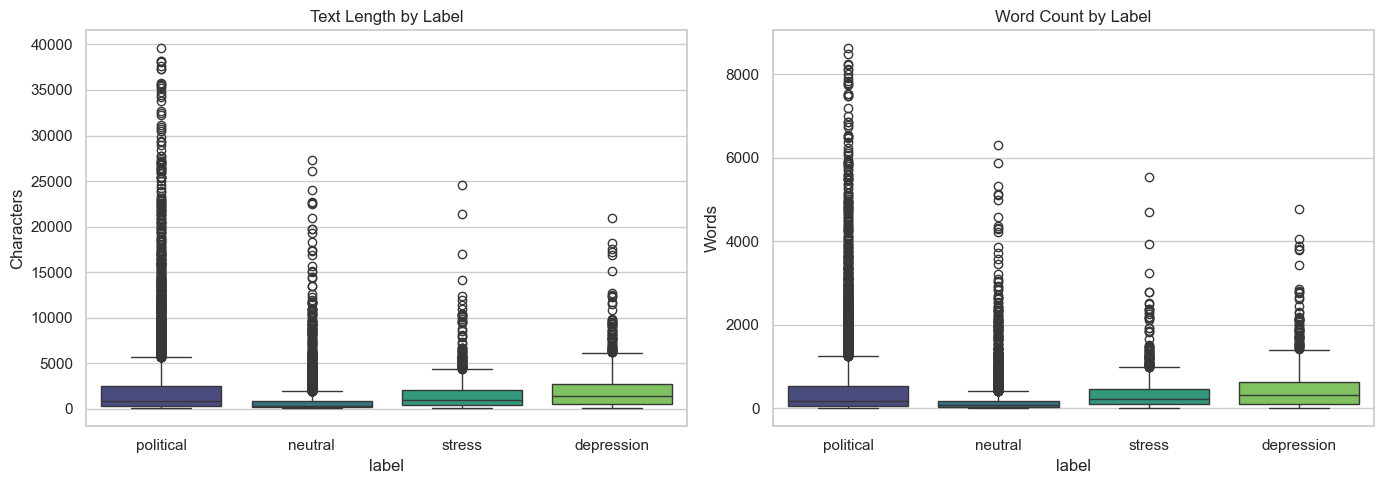

           text_length                                                        \
                 count    mean     std   min    25%     50%     75%      max   
label                                                                          
depression       870.0  2117.4  2528.8  31.0  473.8  1408.5  2743.5  20986.0   
neutral         5660.0   850.0  1758.4  31.0  119.0   303.0   825.0  27350.0   
political       5810.0  2316.4  4260.2  31.0  272.0   790.0  2430.5  39570.0   
stress          1603.0  1479.2  1791.4  32.0  412.5   979.0  1989.0  24517.0   

           word_count                                                  
                count   mean    std  min    25%    50%    75%     max  
label                                                                  
depression      870.0  483.0  570.7  7.0  111.2  323.0  633.5  4761.0  
neutral        5660.0  191.0  391.1  1.0   27.0   70.0  185.0  6299.0  
political      5810.0  511.6  929.3  7.0   63.0  179.5  538.8  8616.0  
stress 

In [6]:
df["text_length"] = df["text_clean"].str.len()
df["word_count"] = df["text_clean"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution per label
sns.boxplot(data=df, x="label", y="text_length", ax=axes[0], palette="viridis")
axes[0].set_title("Text Length by Label")
axes[0].set_ylabel("Characters")

# Word count distribution per label
sns.boxplot(data=df, x="label", y="word_count", ax=axes[1], palette="viridis")
axes[1].set_title("Word Count by Label")
axes[1].set_ylabel("Words")

plt.tight_layout()
plt.show()

print(df.groupby("label")[["text_length", "word_count"]].describe().round(1))